# Face Mask Detection using Pre-trained YOLOv8

## Step 1: Install libraries and load dataset


In [1]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.8 MB/s eta 0:00:00


In [4]:
from google.colab import files
files.upload()

Saving archive (1).zip to archive (1).zip
unzip:  cannot find or open face-mask-dataset.zip, face-mask-dataset.zip.zip or face-mask-dataset.zip.ZIP.


In [11]:

!unzip -q archive\ \(1\).zip -d dataset

In [12]:
!ls dataset

data


In [14]:
!ls dataset/data


with_mask  without_mask


In [15]:

!ls dataset/data/with_mask/

with_mask_1000.jpg  with_mask_1840.jpg	with_mask_267.jpg   with_mask_3518.jpg
with_mask_1001.jpg  with_mask_1841.jpg	with_mask_2680.jpg  with_mask_3519.jpg
with_mask_1002.jpg  with_mask_1842.jpg	with_mask_2681.jpg  with_mask_351.jpg
with_mask_1003.jpg  with_mask_1843.jpg	with_mask_2682.jpg  with_mask_3520.jpg
with_mask_1004.jpg  with_mask_1844.jpg	with_mask_2683.jpg  with_mask_3521.jpg
with_mask_1005.jpg  with_mask_1845.jpg	with_mask_2684.jpg  with_mask_3522.jpg
with_mask_1006.jpg  with_mask_1846.jpg	with_mask_2685.jpg  with_mask_3523.jpg
with_mask_1007.jpg  with_mask_1847.jpg	with_mask_2686.jpg  with_mask_3524.jpg
with_mask_1008.jpg  with_mask_1848.jpg	with_mask_2687.jpg  with_mask_3525.jpg
with_mask_1009.jpg  with_mask_1849.jpg	with_mask_2688.jpg  with_mask_3526.jpg
with_mask_100.jpg   with_mask_184.jpg	with_mask_2689.jpg  with_mask_3527.jpg
with_mask_1010.jpg  with_mask_1850.jpg	with_mask_268.jpg   with_mask_3528.jpg
with_mask_1011.jpg  with_mask_1851.jpg	with_mask_2690.jpg  with_ma

In [16]:

!ls dataset/data/without_mask

without_mask_1000.jpg  without_mask_214.jpg   without_mask_3299.jpg
without_mask_1001.jpg  without_mask_2150.jpg  without_mask_329.jpg
without_mask_1002.jpg  without_mask_2151.jpg  without_mask_32.jpg
without_mask_1003.jpg  without_mask_2152.jpg  without_mask_3300.jpg
without_mask_1004.jpg  without_mask_2153.jpg  without_mask_3301.jpg
without_mask_1005.jpg  without_mask_2154.jpg  without_mask_3302.jpg
without_mask_1006.jpg  without_mask_2155.jpg  without_mask_3303.jpg
without_mask_1007.jpg  without_mask_2156.jpg  without_mask_3304.jpg
without_mask_1008.jpg  without_mask_2157.jpg  without_mask_3305.jpg
without_mask_1009.jpg  without_mask_2158.jpg  without_mask_3306.jpg
without_mask_100.jpg   without_mask_2159.jpg  without_mask_3307.jpg
without_mask_1010.jpg  without_mask_215.jpg   without_mask_3308.jpg
without_mask_1011.jpg  without_mask_2160.jpg  without_mask_3309.jpg
without_mask_1012.jpg  without_mask_2161.jpg  without_mask_330.jpg
without_mask_1013.jpg  without_mask_2162.jpg  withou

In [24]:
import os

with_mask_folder = 'dataset/data/with_mask'
without_mask_folder = 'dataset/data/without_mask'

with_mask_files = os.listdir(with_mask_folder)
without_mask_files = os.listdir(without_mask_folder)

print("with_mask images:", len(with_mask_files))
print("without_mask images:", len(without_mask_files))

my_images = []

for x in with_mask_files[:3]:
  my_images.append(with_mask_folder + '/' + x)

for x in without_mask_files[:3]:
  my_images.append(without_mask_folder + '/' + x)
print("__________________________________________________________")
print(my_images)

with_mask images: 3725
without_mask images: 3828
__________________________________________________________
['dataset/data/with_mask/with_mask_3348.jpg', 'dataset/data/with_mask/with_mask_160.jpg', 'dataset/data/with_mask/with_mask_3219.jpg', 'dataset/data/without_mask/without_mask_2221.jpg', 'dataset/data/without_mask/without_mask_2911.jpg', 'dataset/data/without_mask/without_mask_395.jpg']


In [22]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [25]:
results = model(my_images)


0: 640x640 1 person, 12.2ms
1: 640x640 (no detections), 12.2ms
2: 640x640 1 person, 12.2ms
3: 640x640 7 persons, 12.2ms
4: 640x640 5 persons, 1 potted plant, 12.2ms
5: 640x640 1 person, 12.2ms
Speed: 7.0ms preprocess, 12.2ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 640)


## Step 6: Show the results with bounding boxes

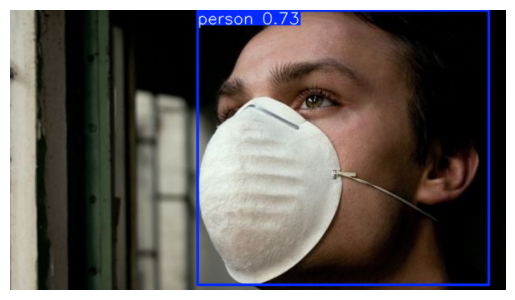

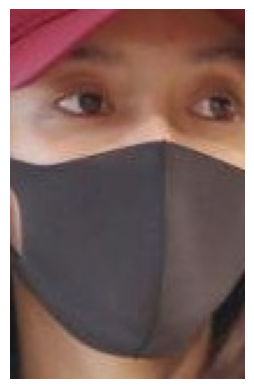

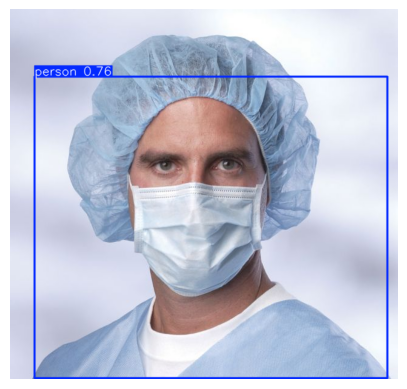

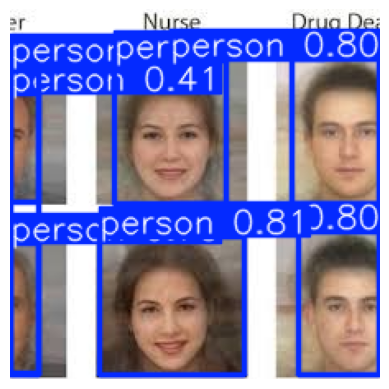

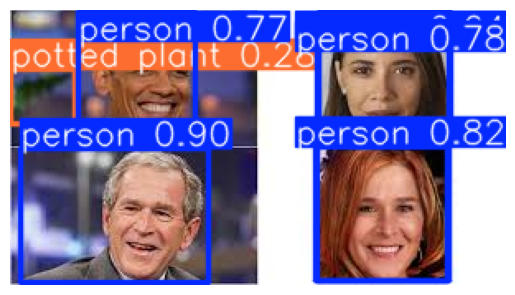

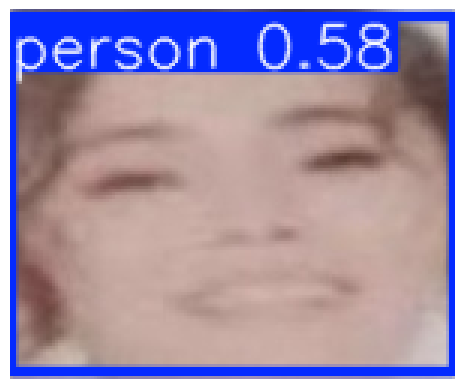

In [26]:
import matplotlib.pyplot as plt

for r in results:
    img_with_boxes = r.plot()
    img_with_boxes = img_with_boxes[:, :, ::-1]
    plt.imshow(img_with_boxes)
    plt.axis('off')
    plt.show()

## Step 7: Save the pictures with boxes on them

In [27]:
import cv2

!mkdir -p output_images

count = 0
for r in results:
    img_with_boxes = r.plot()
    save_name = 'output_images/result_' + str(count) + '.jpg'
    cv2.imwrite(save_name, img_with_boxes)
    count = count + 1

print('Saved', count, 'images in the output_images folder')

Saved 6 images in the output_images folder


In [28]:

!zip -r output_images.zip output_images
from google.colab import files
files.download('output_images.zip')

  adding: output_images/ (stored 0%)
  adding: output_images/result_3.jpg (deflated 3%)
  adding: output_images/result_1.jpg (deflated 3%)
  adding: output_images/result_4.jpg (deflated 2%)
  adding: output_images/result_2.jpg (deflated 6%)
  adding: output_images/result_5.jpg (deflated 3%)
  adding: output_images/result_0.jpg (deflated 6%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>